# MPI Heat Diffusion Graph

This notebook reads the MPI output CSV files and plots the heat distribution with `matplotlib`.

If `matplotlib` is not installed in your Jupyter kernel, run this once in a notebook cell:

```python
%pip install matplotlib
```

In [6]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt

csv_files = [
    Path("output_100.csv"),
    Path("output_1000.csv"),
]

In [7]:
def read_heat_csv(path):
    positions = []
    temperatures = []

    with path.open(newline="", encoding="utf-8-sig") as file:
        reader = csv.DictReader(file)
        for row in reader:
            positions.append(int(row["position"]))
            temperatures.append(float(row["temperature"]))

    return positions, temperatures

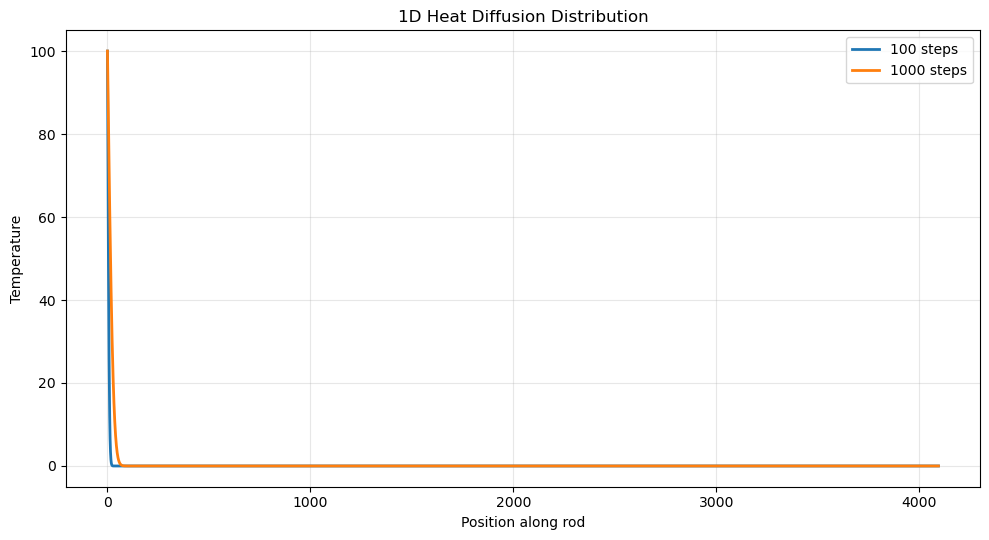

In [8]:
plt.figure(figsize=(10, 5.5))

for csv_file in csv_files:
    positions, temperatures = read_heat_csv(csv_file)
    label = csv_file.stem.replace("output_", "") + " steps"
    plt.plot(positions, temperatures, linewidth=2, label=label)

plt.title("1D Heat Diffusion Distribution")
plt.xlabel("Position along rod")
plt.ylabel("Temperature")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("heat_distribution_matplotlib.png", dpi=200)
plt.show()